Q1

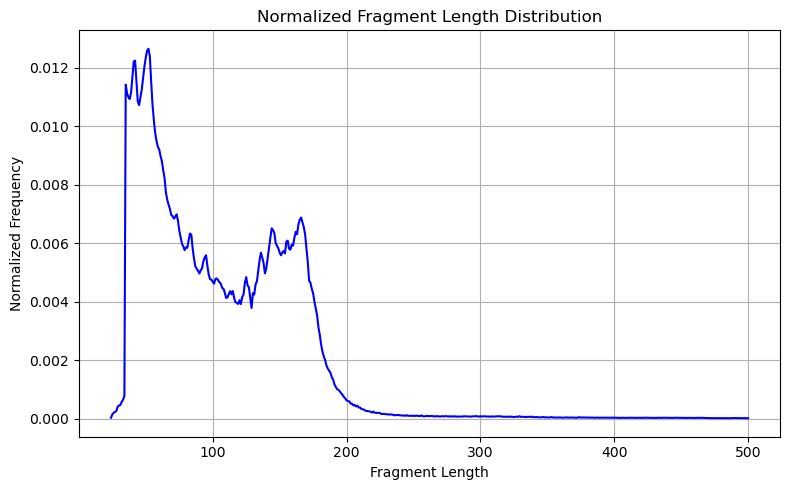

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

# Load BED file data
query_data = pd.read_csv('query.bed', sep='\t', header=None)

# Calculate fragment lengths
fragment_lengths = query_data[2] - query_data[1]

# Count occurrences of each fragment length
length_distribution = Counter(fragment_lengths)

# Normalize frequencies
total_fragments = sum(length_distribution.values())
normalized_distribution = {length: count / total_fragments for length, count in length_distribution.items()}

# Sort by fragment length
sorted_lengths, sorted_frequencies = zip(*sorted(normalized_distribution.items()))

# Convert to DataFrame for plotting
plot_data = pd.DataFrame({
    'Length': sorted_lengths,
    'Frequency': sorted_frequencies
})

# Plot the normalized frequency distribution
plt.figure(figsize=(8, 5))
plt.plot(plot_data['Length'], plot_data['Frequency'], color='blue')
plt.title('Normalized Fragment Length Distribution')
plt.xlabel('Fragment Length')
plt.ylabel('Normalized Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()



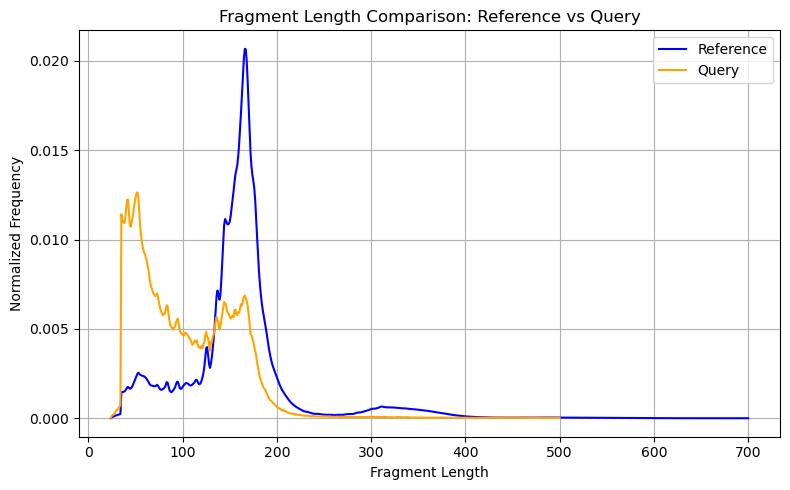

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Load BED file data (query)
query_data = pd.read_csv('query.bed', sep='\t', header=None)

# Calculate fragment lengths
fragment_lengths = query_data[2] - query_data[1]

# Count occurrences of each fragment length
length_distribution = Counter(fragment_lengths)

# Normalize frequencies
total_fragments = sum(length_distribution.values())
normalized_distribution = {length: count / total_fragments for length, count in length_distribution.items()}

# Sort by fragment length
sorted_lengths, sorted_frequencies = zip(*sorted(normalized_distribution.items()))

# Create DataFrame for query plot
query_df = pd.DataFrame({
    'Length': sorted_lengths,
    'Frequency': sorted_frequencies
})

# Load reference histogram data
reference_data = pd.read_csv('reference.hist', sep='\t', header=None)
reference_lengths = reference_data[0]
reference_frequencies = reference_data[1]

# Plot both distributions
plt.figure(figsize=(8, 5))
plt.plot(reference_lengths, reference_frequencies, color='blue', label='Reference')
plt.plot(query_df['Length'], query_df['Frequency'], color='orange', label='Query')

plt.title('Fragment Length Comparison: Reference vs Query')
plt.xlabel('Fragment Length')
plt.ylabel('Normalized Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


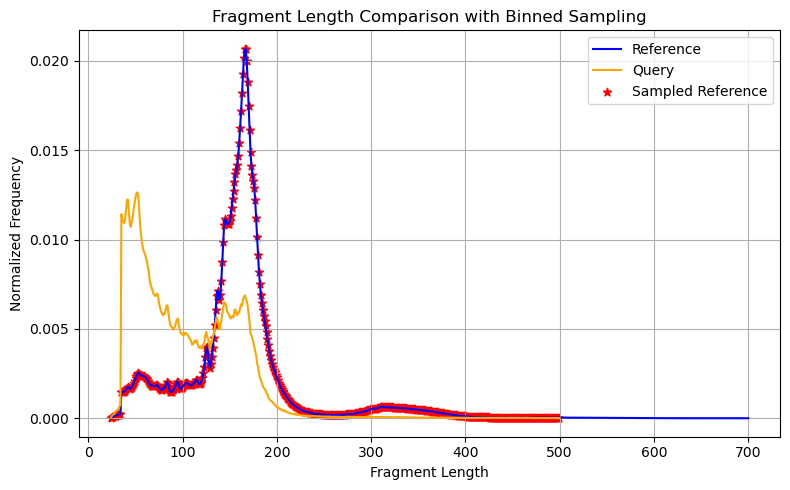

In [13]:
# Define bin edges and labels
bin_edges = list(range(0, 510, 10))
bin_labels = [f"{i}-{i+10}" for i in range(0, 500, 10)]

# Add bin labels to query and reference data
query_df['Bin'] = pd.cut(query_df['Length'], bins=bin_edges, labels=bin_labels, right=False)
reference_data['Bin'] = pd.cut(reference_data[0], bins=bin_edges, labels=bin_labels, right=False)

# Count how many items fall into each bin
query_bin_counts = query_df['Bin'].value_counts().sort_index()
reference_bin_counts = reference_data['Bin'].value_counts().sort_index()

# Initialize list to store sampled rows from reference
matched_sample_rows = []

# Match query and reference samples by bin
for label in bin_labels:
    count_query = query_bin_counts.get(label, 0)
    count_reference = reference_bin_counts.get(label, 0)
    sample_size = min(count_query, count_reference)
    
    if sample_size > 0:
        reference_subset = reference_data[reference_data['Bin'] == label]
        sampled_subset = reference_subset.sample(n=sample_size, random_state=42)
        matched_sample_rows.append(sampled_subset)

# Combine all sampled reference rows into a new DataFrame
sampled_reference_df = pd.concat(matched_sample_rows, ignore_index=True)

# Plot original reference, query, and sampled reference data
plt.figure(figsize=(8, 5))
plt.plot(reference_data[0], reference_data[1], color='blue', label='Reference')
plt.plot(query_df['Length'], query_df['Frequency'], color='orange', label='Query')
plt.scatter(sampled_reference_df[0], sampled_reference_df[1], color='red', marker='*', label='Sampled Reference')

plt.title('Fragment Length Comparison with Binned Sampling')
plt.xlabel('Fragment Length')
plt.ylabel('Normalized Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
